Number of States : 16
Number of Actions: 4

Final Q-table:
[[0.256 0.889 0.504 0.331]
 [0.03  0.    0.549 0.003]
 [0.097 0.553 0.014 0.081]
 [0.017 0.    0.03  0.023]
 [0.254 0.904 0.    0.386]
 [0.    0.    0.    0.   ]
 [0.    0.975 0.    0.006]
 [0.    0.    0.    0.   ]
 [0.392 0.    0.922 0.417]
 [0.641 0.169 0.932 0.   ]
 [0.954 0.989 0.    0.935]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.242 0.925 0.094]
 [0.938 0.99  1.    0.98 ]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.889 0.549 0.553 0.03 ]
 [0.904 0.    0.975 0.   ]
 [0.922 0.932 0.989 0.   ]
 [0.    0.925 1.    0.   ]]

Name: Vignesh M
Register Number: 212223240176

Learned Policy:
[['D' 'R' 'D' 'R']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.938


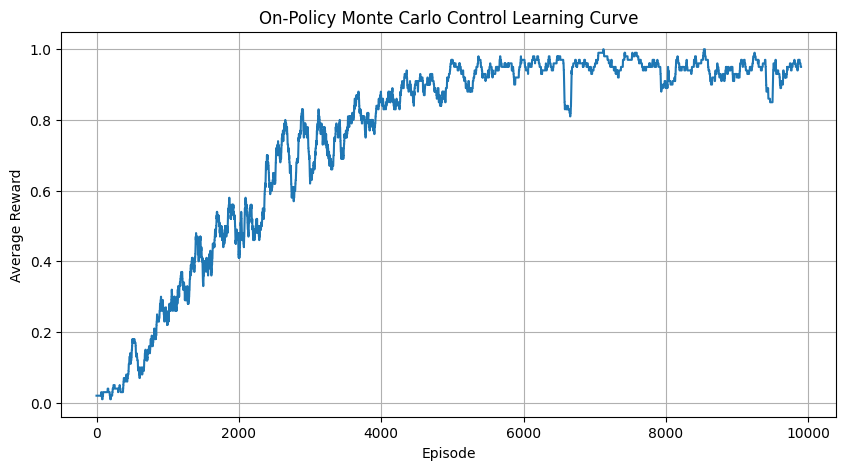

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


# -------------------------------------------------
# 1. Create Environment
# -------------------------------------------------

env = gym.make(
    "FrozenLake-v1",
    is_slippery=False
)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of States :", n_states)
print("Number of Actions:", n_actions)


# -------------------------------------------------
# 2. Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))


# -------------------------------------------------
# 3. Parameters
# -------------------------------------------------

alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

num_episodes = 10000

# Store reward of every episode
episode_rewards = []


# -------------------------------------------------
# 4. Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    else:
        return np.argmax(Q[state])


# -------------------------------------------------
# 5. Monte Carlo Control
# -------------------------------------------------

for episode in range(num_episodes):

    # Reset environment
    state, info = env.reset()

    # Store episode as:
    # (state, action, reward)
    episode_data = []

    total_reward = 0

    terminated = False
    truncated = False


    # -------------------------------------------------
    # Generate Complete Episode
    # -------------------------------------------------

    while not terminated and not truncated:

        # Select action using epsilon-greedy
        action = epsilon_greedy_action(
            state,
            epsilon
        )

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Store experience
        episode_data.append(
            (state, action, reward)
        )

        # Add reward
        total_reward += reward

        # Move to next state
        state = next_state


    # -------------------------------------------------
    # Calculate Return and Update Q-table
    # -------------------------------------------------

    G = 0

    # Traverse episode backwards
    for state, action, reward in reversed(episode_data):

        # Calculate return
        G = reward + gamma * G

        # Incremental Monte Carlo update
        Q[state, action] = (
            Q[state, action]
            + alpha * (G - Q[state, action])
        )


    # -------------------------------------------------
    # Store Episode Reward
    # -------------------------------------------------

    episode_rewards.append(total_reward)


    # -------------------------------------------------
    # Decay Epsilon
    # -------------------------------------------------

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


# ============================================================
# 6. Calculate State-Value Function
# ============================================================

state_values = np.max(Q, axis=1)


# ============================================================
# 7. Calculate Optimal Policy
# ============================================================

optimal_policy = np.argmax(Q, axis=1)


# ============================================================
# 8. Display Results
# ============================================================


def print_policy(policy):

    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [
            action_symbols[action]
            for action in policy
        ]
    ).reshape(4, 4)

    print("\nName: Vignesh M")
    print("Register Number: 212223240176")

    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):

    print("\nEstimated State-Value Function:")

    print(
        np.round(
            values.reshape(4, 4),
            3
        )
    )


# -------------------------------------------------
# Final Q-table
# -------------------------------------------------

print("\nFinal Q-table:")

print(
    np.round(
        Q,
        3
    )
)


# -------------------------------------------------
# State-Value Function
# -------------------------------------------------

print_value_function(
    state_values
)


# -------------------------------------------------
# Learned Policy
# -------------------------------------------------

print_policy(
    optimal_policy
)


# -------------------------------------------------
# Average Reward
# -------------------------------------------------

success_rate = np.mean(
    episode_rewards[-1000:]
)

print(
    "\nAverage reward over last 1000 episodes:",
    round(success_rate, 3)
)


# ============================================================
# 9. Learning Curve
# ============================================================

window = 100

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)


plt.figure(figsize=(10, 5))

plt.plot(
    moving_average
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "On-Policy Monte Carlo Control Learning Curve"
)

plt.grid(True)

plt.show()


# ============================================================
# 10. Close Environment
# ============================================================

env.close()